Project Overview

# Reproducible Titanic Survival Analysis

This project performs a full end-to-end data science workflow:
- Data acquisition
- Cleaning & feature engineering
- Exploratory Data Analysis
- Modeling
- Interpretation

All results are reproducible.

Setup & Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

sns.set(style="whitegrid")

# Ensure folders exist
# Ensure folders exist in the current directory
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print("Folders created or already exist.")

Folders created or already exist.


Download & Save Raw Data

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = pd.read_csv(url)
df_raw.to_csv('data/raw/titanic_raw.csv', index=False)
df_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Data Cleaning & Feature Engineering

In [3]:
df = df_raw.copy()

# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Create Title feature
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Family Size
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# Has Cabin
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)

# Drop unnecessary columns
df.drop(['Name','Ticket','Cabin','PassengerId'], axis=1, inplace=True)

df.to_csv('data/processed/titanic_cleaned.csv', index=False)
df.head()

C:\Users\cyril\AppData\Local\Temp\ipykernel_28280\2747507207.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\cyril\AppData\Local\Temp\ipykernel_28280\2747507207.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_Size,Has_Cabin
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,0


Exploratory Data Analysis

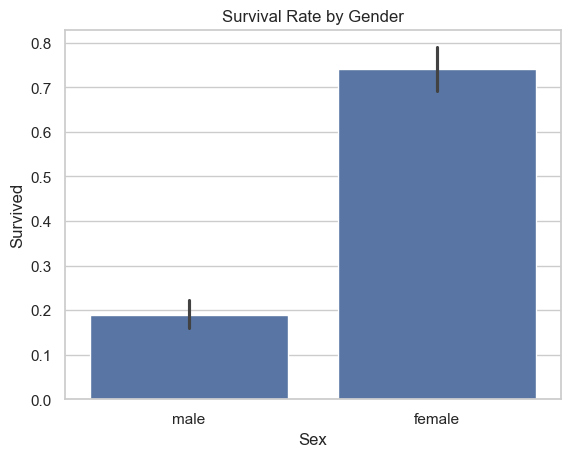

In [4]:
plt.figure()
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.savefig('figures/survival_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

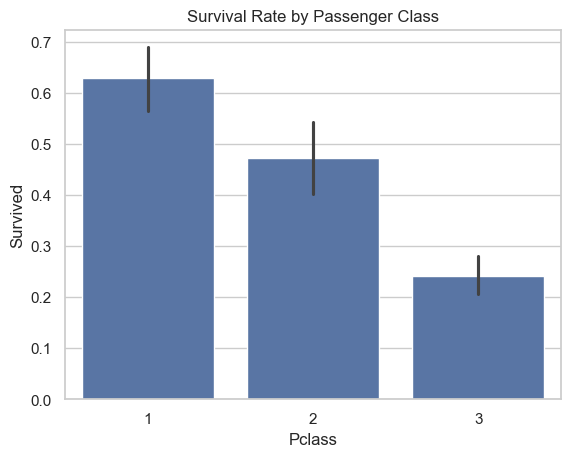

In [5]:
plt.figure()
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.savefig('figures/survival_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

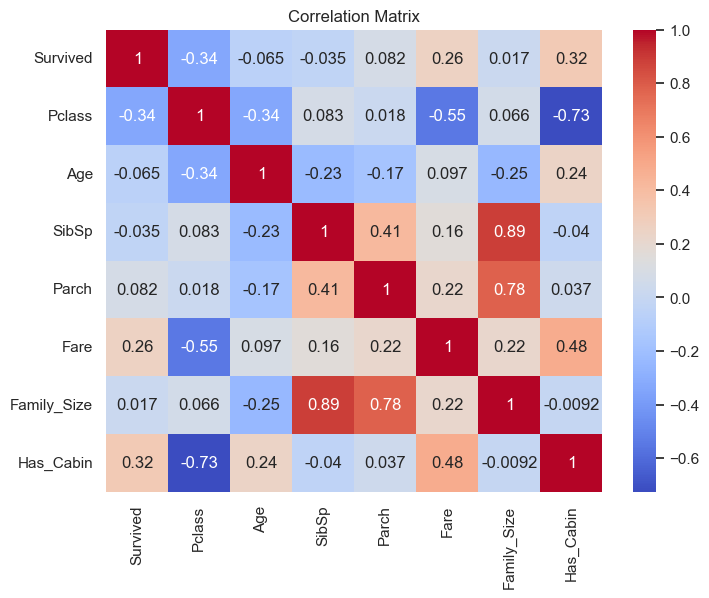

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.savefig('figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Modeling

Encode Categorical Variables

In [7]:
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic Regression

In [8]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_prob_log)

Decision Tree

In [9]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:,1]

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

Model Comparison Table

In [10]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [acc_log, acc_tree],
    'F1-Score': [f1_log, f1_tree],
    'AUC': [auc_log, auc_tree]
})

results.to_csv('../figures/model_comparison.csv', index=False)
results

,Model,Accuracy,F1-Score,AUC
0,Logistic Regression,0.821229,0.786667,0.887259
1,Decision Tree,0.826816,0.791946,0.832304


Conclusions

## Key Findings

- Women had significantly higher survival rates.
- 1st class passengers were more likely to survive.
- Engineered features improved predictive performance.
- Logistic regression slightly outperformed decision tree.

## Limitations
- Small dataset
- Historical context missing
- No external validation dataset